# RQ1: Hybrid Anonymization + DP-SGD for Emotion Detection

**Research Question**: How does a hybrid privacy framework that combines anonymized text preprocessing with Differentially Private SGD affect privacy risk mitigation and emotion detection performance in mental-health chatbot models, compared to DP-only and non-private baselines?

## Methodology:
1. Train 4 RoBERTa-base variants:
   - **V0_BASELINE**: Raw text (no privacy)
   - **V1_ANONYM**: Anonymized text only
   - **V2_DP_SGD**: DP-SGD on raw text (ε=8, δ=1e-5)
   - **V3_HYBRID**: DP-SGD on anonymized text (ε=8, δ=1e-5), using the same privacy budget as V2

2. Evaluate utility (F1-macro and F1-micro) and privacy (loss-based memorization/MIA)
3. Compare hybrid vs standalone effectiveness and trade-offs

In [1]:
!pip install opacus


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# Import necessary libraries
import os
import sys
import pathlib
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score
from tqdm import tqdm
import warnings
from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager

warnings.filterwarnings('ignore')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

In [ ]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print("Not running in Colab environment")

# Find Project Root and Data Paths
if IN_COLAB:
    POSSIBLE_ROOTS = [
        '/content/drive/MyDrive',
        '/content/drive/My Drive'
    ]
    PROJECT_ROOT = None
    for pr in POSSIBLE_ROOTS:
        if os.path.exists(pr):
            PROJECT_ROOT = pathlib.Path(pr)
            break

    if PROJECT_ROOT is None:
        print("WARNING: Project root not found in Google Drive. Creating default paths.")
        PROJECT_ROOT = pathlib.Path('/content/drive/MyDrive')
else:
    PROJECT_ROOT = pathlib.Path(os.getcwd())
    if 'src' in PROJECT_ROOT.parts:
        PROJECT_ROOT = PROJECT_ROOT.parents[PROJECT_ROOT.parts.index('src') - 1]

print(f"Project Root: {PROJECT_ROOT}")
sys.path.append(str(PROJECT_ROOT))

RAW_PATH = PROJECT_ROOT / 'content' / 'data' / 'raw' / 'go_emotions_dataset.csv'
CLEANED_PATH = PROJECT_ROOT / 'content' / 'data' / 'processed' / 'go_emotions_cleaned.csv'
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'rq1_variants'
REPORT_DIR = PROJECT_ROOT / 'reports' / 'rq1'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

# Load datasets
df_raw = pd.read_csv(RAW_PATH)
df_cleaned = pd.read_csv(CLEANED_PATH)

print(f"Raw: {df_raw.shape} | Cleaned: {df_cleaned.shape}")

# Emotion columns
emotion_columns = ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring',
                   'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval',
                   'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief',
                   'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization',
                   'relief', 'remorse', 'sadness', 'surprise', 'neutral']
df_cleaned['labels'] = df_cleaned[emotion_columns].values.tolist()

# Unique labels count
num_emotions = len(emotion_columns)

# Tokenize the dataset
tokenizer = AutoTokenizer.from_pretrained("roberta-base")
df_cleaned['input_ids'] = df_cleaned['text'].apply(
    lambda x: tokenizer.encode(x, add_special_tokens=True, truncation=True, max_length=128)
    )

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
padded_inputs = data_collator([{"input_ids": input_id} for input_id in df_cleaned['input_ids']])
df_cleaned['input_ids'] = list(padded_inputs['input_ids'])

# Convert input_ids and labels to proper tensor format
df_cleaned['input_ids'] = df_cleaned['input_ids'].apply(lambda x: torch.tensor(x, dtype=torch.long))
df_cleaned['labels'] = df_cleaned['labels'].apply(lambda x: torch.tensor(x, dtype=torch.float))

# Define the model 
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=num_emotions)
model.to(device)

Prepare Train/Val/Test Splits

In [4]:
from sklearn.model_selection import train_test_split

meta_cols = {'id', 'text', 'example_very_unclear', 'clean_text', 'num_emotions', 'emotion_bin'}
emotion_cols = [col for col in df_raw.columns if col not in meta_cols]
print(f"emotion_cols: {len(emotion_cols)} → {emotion_cols}")

print(f"Emotion columns: {len(emotion_cols)}")

emotion_cols: 28 → ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
Emotion columns: 28


In [5]:
# Merge datasets on ID
df = df_raw.copy()
df = df.merge(df_cleaned[['id', 'clean_text']], on='id', how='inner')

# Stratify by high-emotion texts
df['num_emotions'] = df[emotion_cols].sum(axis=1)

# Use qcut with duplicates='drop' to handle skewed distributions
df['emotion_bin'] = pd.qcut(df['num_emotions'], q=3, duplicates='drop')

# Dynamically rename categories to match expected labels
n_bins = len(df['emotion_bin'].cat.categories)
label_map = {i: label for i, label in enumerate(['low', 'med', 'high'][:n_bins])}
df['emotion_bin'] = df['emotion_bin'].cat.rename_categories(label_map)

print(f"Stratification created {n_bins} bins: {df['emotion_bin'].value_counts().sort_index().to_dict()}")

# 60% train, 20% val, 20% test
train_idx, temp_idx = train_test_split(
    range(len(df)), test_size=0.4, random_state=42, stratify=df['emotion_bin']
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=42, stratify=df.loc[temp_idx, 'emotion_bin']
)

df_train = df.iloc[train_idx].reset_index(drop=True)
df_val = df.iloc[val_idx].reset_index(drop=True)
df_test = df.iloc[test_idx].reset_index(drop=True)

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

Stratification created 2 bins: {Interval(-0.001, 1.0, closed='right'): 173342, Interval(1.0, 12.0, closed='right'): 35848}
Train: 125514 | Val: 41838 | Test: 41838


Create Text Variants

In [6]:
def prepare_variant_texts(df_split, text_col='text'):
    return df_split[text_col].astype(str).str.lower().tolist()

# Prepare V0_BASELINE variant using the original 'text' column
train_v0 = prepare_variant_texts(df_train, 'text')
val_v0 = prepare_variant_texts(df_val, 'text')
test_v0 = prepare_variant_texts(df_test, 'text')

# Prepare V1_ANONYM variant using the anonymized 'clean_text' column
train_v1 = prepare_variant_texts(df_train, 'clean_text')
val_v1 = prepare_variant_texts(df_val, 'clean_text')
test_v1 = prepare_variant_texts(df_test, 'clean_text')

print(f"Sample V0: {train_v0[0][:100]}...")
print(f"Sample V1: {train_v1[0][:100]}...")

Sample V0: sunni scum - check saudi vermin - check what more can you expect, this is the lowest form life can t...
Sample V1: sunni scum - check saudi vermin - check what more can you expect, this is the lowest form life can t...


Multi-Label Emotion Dataset

In [ ]:
# Custom Dataset for emotion classification
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx]).float()
        }


# Prepare labels for each split
train_labels = df_train[emotion_cols].values.astype(np.float32)
val_labels = df_val[emotion_cols].values.astype(np.float32)
test_labels = df_test[emotion_cols].values.astype(np.float32)

print(f"Label shapes: {train_labels.shape}")

Label shapes: (125514, 28)


Model Training Loop

In [ ]:
class RobertaHeadOnlyClassifier(torch.nn.Module):
    """
    Freeze ALL RoBERTa weights. Train a 2-layer MLP head on mean-pooled embeddings.
    Improvements over single Linear:
      1. Mean pooling (not CLS) — gives richer frozen representations
      2. Bottleneck MLP (768→256→28) — learns non-linear emotion boundaries
      3. Dropout — regularises against DP noise
    Total trainable: ~200K params (better signal/noise ratio under DP).
    """
    def __init__(self, roberta_model, num_labels, hidden_dim=256, dropout=0.1):
        super().__init__()
        self.roberta = roberta_model.roberta
        hidden_size  = roberta_model.config.hidden_size

        for param in self.roberta.parameters():
            param.requires_grad = False

        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(hidden_size, hidden_dim),
            torch.nn.GELU(),
            torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, num_labels),
        )

        # Xavier init for all linear layers
        for m in self.classifier:
            if isinstance(m, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                torch.nn.init.zeros_(m.bias)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        # Mean pooling
        hidden = outputs.last_hidden_state                       
        mask   = attention_mask.unsqueeze(-1).float()             
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1)    
        return self.classifier(pooled)


class RobertaLinearClassifier(torch.nn.Module):
    """
    Freeze layers 0-9, train layers 10-11 + linear head.
    Used for NON-DP variants (V0, V1) where noise is not a concern.
    """
    def __init__(self, roberta_model, num_labels, freeze_layers=10):
        super().__init__()
        self.roberta  = roberta_model.roberta
        hidden_size   = roberta_model.config.hidden_size

        for param in self.roberta.embeddings.parameters():
            param.requires_grad = False
        for layer in self.roberta.encoder.layer[:freeze_layers]:
            for param in layer.parameters():
                param.requires_grad = False
        for layer in self.roberta.encoder.layer[freeze_layers:]:
            for param in layer.parameters():
                param.requires_grad = True

        self.classifier = torch.nn.Linear(hidden_size, num_labels)
        torch.nn.init.xavier_uniform_(self.classifier.weight)
        torch.nn.init.zeros_(self.classifier.bias)

    def forward(self, input_ids, attention_mask):
        outputs    = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        return self.classifier(cls_output)

In [ ]:
def find_best_threshold(model, val_loader, val_labels_val, device, is_dp=False):
    """
    Sweep thresholds on validation set and return the one maximising F1-macro.
    """
    model.eval()
    val_preds_raw = []

    with torch.no_grad():
        for batch in val_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs        = model(input_ids=input_ids, attention_mask=attention_mask)
            logits         = outputs if isinstance(outputs, torch.Tensor) else outputs.logits
            probs          = torch.sigmoid(logits).cpu().numpy()
            val_preds_raw.append(probs)

    val_preds_raw = np.vstack(val_preds_raw)

    # Catch sigmoid collapse before sweep
    mean_prob      = val_preds_raw.mean()
    frac_above_05  = (val_preds_raw > 0.05).mean()
    frac_above_30  = (val_preds_raw > 0.30).mean()
    logit_proxy    = np.log(val_preds_raw.mean() / (1 - val_preds_raw.mean() + 1e-9))
    print(f"   [diag] mean_prob={mean_prob:.4f} | "
          f">0.05: {frac_above_05:.2%} | "
          f">0.30: {frac_above_30:.2%} | "
          f"mean_logit≈{logit_proxy:.3f}")

    best_t, best_f1 = 0.3, 0.0
    for t in np.arange(0.05, 0.95, 0.05):
        preds = (val_preds_raw > t).astype(int)
        f1    = f1_score(val_labels_val, preds, average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    return best_t, best_f1



def train_emotion_model(variant_name, train_texts, val_texts,
                        train_labels_val, val_labels_val,
                        use_dp=False, epsilon=8.0, delta=1e-5,
                        max_grad_norm=1.2, epochs=3, threshold=0.3):

    print(f"\n{'='*60}")
    print(f"Training: {variant_name}")
    print(f"DP: {use_dp} (ε={epsilon}, δ={delta})" if use_dp else "DP: False")
    print(f"{'='*60}")

    import gc
    gc.collect()
    torch.cuda.empty_cache()

    model_name = 'roberta-base'
    tokenizer  = AutoTokenizer.from_pretrained(model_name)
    num_labels = train_labels_val.shape[1]

    
    if use_dp:
        physical_batch_size = 32
        logical_batch_size  = 256
        lr                  = 1e-3   
    else:
        physical_batch_size = 16
        logical_batch_size  = 16
        lr                  = 2e-5

    # Build model
    base_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
        problem_type='multi_label_classification'
    )

    if use_dp:
        model = RobertaHeadOnlyClassifier(
            roberta_model=base_model,
            num_labels=num_labels,
            hidden_dim=256,
            dropout=0.1,
        )
        arch_label = "MLP HEAD + MEAN POOL (DP)"
    else:
        model = RobertaLinearClassifier(
            roberta_model=base_model,
            num_labels=num_labels,
            freeze_layers=10
        )
        arch_label = "LAYERS 10-11 + HEAD"
    del base_model

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f" Architecture  : {arch_label}")
    print(f" Trainable     : {trainable:,} / {total:,} params")

    model.to(device)

    label_pos  = train_labels_val.sum(axis=0)
    label_neg  = len(train_labels_val) - label_pos
    raw_weight = label_neg / (label_pos + 1e-6)

    if use_dp:
        # DP: mild sqrt dampening with tight cap
        # High pos_weight amplifies rare-class gradients which get clipped
        # max_grad_norm → destroys common-class signal under noise
        pos_weight = torch.tensor(
            np.sqrt(raw_weight),
            dtype=torch.float32
        ).clamp(min=1.0, max=3.0).to(device)
    else:
        # Non-DP: sqrt dampening + moderate cap
        # Full raw_weight (mean ~18) causes over-prediction of rare classes,
        # forcing threshold to 0.80+ to compensate → fragile and suboptimal
        pos_weight = torch.tensor(
            np.sqrt(raw_weight),
            dtype=torch.float32
        ).clamp(min=1.0, max=10.0).to(device)

    print(f" pos_weight    : min={pos_weight.min():.1f}, "
          f"max={pos_weight.max():.1f}, "
          f"mean={pos_weight.mean():.1f}")

    train_dataset = EmotionDataset(train_texts, train_labels_val, tokenizer)
    val_dataset   = EmotionDataset(val_texts,   val_labels_val,   tokenizer)
    train_loader  = DataLoader(
        train_dataset,
        batch_size=logical_batch_size,
        shuffle=True,
        drop_last=True
    )
    val_loader = DataLoader(val_dataset, batch_size=32)

    optimizer = Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    # DP-SGD via Opacus 
    privacy_engine = None
    if use_dp:
        try:
            from opacus.validators import ModuleValidator
            model = ModuleValidator.fix(model)
            model.to(device)
            validation_errors = ModuleValidator.validate(model, strict=False)
            if validation_errors:
                print(f" Opacus validate: {len(validation_errors)} non-blocking issue(s); using strict=False")
                for err in validation_errors[:2]:
                    print(f"   - {err}")
                if len(validation_errors) > 2:
                    print(f"   ... plus {len(validation_errors) - 2} more")

            
            # Rebuild optimizer so parameter groups match the validated model exactly.
            optimizer = Adam(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=lr
            )

            privacy_engine = PrivacyEngine()
            model.train()
            model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
                module=model,
                optimizer=optimizer,
                data_loader=train_loader,
                target_epsilon=epsilon,
                target_delta=delta,
                epochs=epochs,
                max_grad_norm=max_grad_norm,
                poisson_sampling=False,
                strict=False,
            )
            noise_mult      = optimizer.noise_multiplier
            effective_noise = noise_mult * max_grad_norm
            steps_per_epoch = len(train_dataset) // logical_batch_size

            print(f" DP-SGD        : ε={epsilon}, δ={delta}")
            print(f" Noise         : σ={noise_mult:.4f} | "
                  f"effective std={effective_noise:.4f}")
            print(f" Batch         : logical={logical_batch_size}, "
                  f"physical={physical_batch_size}")
            print(f" Steps/epoch   : {steps_per_epoch} | "
                  f"Total: {steps_per_epoch * epochs}")

            if effective_noise > 2.0:
                print(f" WARNING: noise std {effective_noise:.2f} "
                      f"may overwhelm gradients")

        except Exception as e:
            print(f" ERROR setting up DP: {e}")
            import traceback; traceback.print_exc()
            use_dp, privacy_engine = False, None

   
    steps_per_epoch = len(train_dataset) // logical_batch_size
    total_steps     = steps_per_epoch * epochs
    if use_dp:
        scheduler = None
    else:
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(0.1 * total_steps),
            num_training_steps=total_steps
        )

    # Training loop 
    best_f1        = 0.0
    best_threshold = threshold
    epoch_results  = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        model.train()
        train_loss  = 0.0
        num_batches = 0

        if use_dp:
            with BatchMemoryManager(
                data_loader=train_loader,
                max_physical_batch_size=physical_batch_size,
                optimizer=optimizer,
            ) as memory_safe_loader:
                for batch in tqdm(memory_safe_loader, desc='Training (DP)'):
                    optimizer.zero_grad()
                    input_ids      = batch['input_ids'].to(device)
                    attention_mask = batch['attention_mask'].to(device)
                    labels         = batch['labels'].to(device)
                    logits         = model(
                        input_ids=input_ids,
                        attention_mask=attention_mask
                    )
                    loss = torch.nn.functional.binary_cross_entropy_with_logits(
                        logits, labels, pos_weight=pos_weight
                    )
                    loss.backward()
                    optimizer.step()
                    train_loss  += loss.item()
                    num_batches += 1
        else:
            for batch in tqdm(train_loader, desc='Training'):
                optimizer.zero_grad()
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels         = batch['labels'].to(device)
                logits         = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )
                loss = torch.nn.functional.binary_cross_entropy_with_logits(
                    logits, labels, pos_weight=pos_weight
                )
                loss.backward()
                optimizer.step()
                if scheduler:
                    scheduler.step()
                train_loss  += loss.item()
                num_batches += 1

        avg_loss  = train_loss / max(num_batches, 1)
        eps_spent = (privacy_engine.get_epsilon(delta=delta)
                     if (use_dp and privacy_engine) else 0.0)
        print(f" Train Loss: {avg_loss:.4f} | ε spent: {eps_spent:.2f}")

        opt_threshold, f1_macro = find_best_threshold(
            model, val_loader, val_labels_val, device, is_dp=use_dp
        )
        print(f" Val F1-macro: {f1_macro:.4f} (threshold={opt_threshold:.2f})")

        if f1_macro > best_f1:
            best_f1        = f1_macro
            best_threshold = opt_threshold
            torch.save(
                model.state_dict(),
                os.path.join(OUTPUT_DIR, f'{variant_name}_best.pt')
            )

        epoch_results.append({
            'epoch':   epoch + 1,
            'loss':    avg_loss,
            'f1':      f1_macro,
            'epsilon': eps_spent
        })

    print(f"\n Best F1: {best_f1:.4f} (threshold={best_threshold:.2f})")
    model.cpu()
    torch.cuda.empty_cache()

    return {
        'model':     model,
        'tokenizer': tokenizer,
        'best_f1':   best_f1,
        'results':   pd.DataFrame(epoch_results),
        'variant':   variant_name,
        'threshold': best_threshold,
        'is_dp':     use_dp
    }

## Hybrid Architecture Upgrade 

This patch upgrades the DP head used by V3_HYBRID to improve utility under DP noise while keeping privacy settings unchanged.

- Adds multi-pooling features (CLS + masked mean + learned attention)
- Uses a gated fusion block for anonymized-text robustness
- Keeps RoBERTa backbone frozen (still DP-friendly)
- Keeps V2_DP_SGD unchanged by default for clean comparison

In [ ]:
import torch

# Hybrid architecture patch for V3_HYBRID (drop-in, keeps existing pipeline intact)

class RobertaHybridFusionDPClassifier(torch.nn.Module):
    """
    DP-friendly hybrid head:
    - Frozen RoBERTa backbone
    - Multi-pooling representation: CLS + masked mean + learned attention pooling
    - Gated fusion (mean vs attention) to better handle anonymized text
    - Residual classifier branch for stable gradients under DP noise
    """
    def __init__(self, roberta_model, num_labels, hidden_dim=256, gate_dim=128, dropout=0.15):
        super().__init__()
        self.roberta = roberta_model.roberta
        hidden_size = roberta_model.config.hidden_size

        for p in self.roberta.parameters():
            p.requires_grad = False

        self.attn_query = torch.nn.Parameter(torch.randn(hidden_size) * 0.02)

        self.gate = torch.nn.Sequential(
            torch.nn.Linear(hidden_size * 2, gate_dim),
            torch.nn.GELU(),
            torch.nn.Linear(gate_dim, hidden_size),
            torch.nn.Sigmoid(),
        )

        feat_dim = hidden_size * 2  # [CLS || fused(mean, attn)]
        self.feature_norm = torch.nn.LayerNorm(feat_dim)
        self.proj = torch.nn.Linear(feat_dim, hidden_dim)
        self.act = torch.nn.GELU()
        self.drop = torch.nn.Dropout(dropout)
        self.out = torch.nn.Linear(hidden_dim, num_labels)

        self.skip = torch.nn.Linear(feat_dim, num_labels, bias=False)

        for m in self.modules():
            if isinstance(m, torch.nn.Linear):
                torch.nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)

        hidden = outputs.last_hidden_state  # (B, S, H)
        mask = attention_mask.unsqueeze(-1).float()  # (B, S, 1)
        denom = mask.sum(dim=1).clamp(min=1.0)

        cls_pool = hidden[:, 0, :]
        mean_pool = (hidden * mask).sum(dim=1) / denom

        attn_scores = torch.einsum('bsh,h->bs', hidden, self.attn_query)
        attn_scores = attn_scores.masked_fill(attention_mask == 0, -1e4)
        attn_weights = torch.softmax(attn_scores, dim=1).unsqueeze(-1)
        attn_pool = (hidden * attn_weights).sum(dim=1)

        gate = self.gate(torch.cat([mean_pool, attn_pool], dim=-1))
        fused_pool = gate * attn_pool + (1.0 - gate) * mean_pool

        feat = torch.cat([cls_pool, fused_pool], dim=-1)
        feat = self.feature_norm(feat)

        main_logits = self.out(self.drop(self.act(self.proj(feat))))
        skip_logits = self.skip(feat)
        return main_logits + 0.2 * skip_logits


APPLY_HYBRID_ARCH_UPGRADE = True
APPLY_HYBRID_ARCH_UPGRADE_TO_V2 = False


# Keep original train function available, wrap only once.
if '_orig_train_emotion_model' not in globals():
    _orig_train_emotion_model = train_emotion_model


def train_emotion_model(variant_name, train_texts, val_texts,
                        train_labels_val, val_labels_val,
                        use_dp=False, epsilon=8.0, delta=1e-5,
                        max_grad_norm=1.2, epochs=3, threshold=0.3):
    if not APPLY_HYBRID_ARCH_UPGRADE:
        return _orig_train_emotion_model(
            variant_name=variant_name,
            train_texts=train_texts,
            val_texts=val_texts,
            train_labels_val=train_labels_val,
            val_labels_val=val_labels_val,
            use_dp=use_dp,
            epsilon=epsilon,
            delta=delta,
            max_grad_norm=max_grad_norm,
            epochs=epochs,
            threshold=threshold,
        )

    use_fusion_head = use_dp and (
        variant_name == 'V3_HYBRID' or APPLY_HYBRID_ARCH_UPGRADE_TO_V2
    )

    if not use_fusion_head:
        return _orig_train_emotion_model(
            variant_name=variant_name,
            train_texts=train_texts,
            val_texts=val_texts,
            train_labels_val=train_labels_val,
            val_labels_val=val_labels_val,
            use_dp=use_dp,
            epsilon=epsilon,
            delta=delta,
            max_grad_norm=max_grad_norm,
            epochs=epochs,
            threshold=threshold,
        )

    global RobertaHeadOnlyClassifier
    _old_head_class = RobertaHeadOnlyClassifier
    RobertaHeadOnlyClassifier = RobertaHybridFusionDPClassifier

    try:
        print(f"[ARCH PATCH] Fusion DP head enabled for {variant_name}")
        return _orig_train_emotion_model(
            variant_name=variant_name,
            train_texts=train_texts,
            val_texts=val_texts,
            train_labels_val=train_labels_val,
            val_labels_val=val_labels_val,
            use_dp=use_dp,
            epsilon=epsilon,
            delta=delta,
            max_grad_norm=max_grad_norm,
            epochs=epochs,
            threshold=threshold,
        )
    finally:
        RobertaHeadOnlyClassifier = _old_head_class


print(
    f"Hybrid architecture patch loaded. Enabled={APPLY_HYBRID_ARCH_UPGRADE}, "
    f"Apply to V2={APPLY_HYBRID_ARCH_UPGRADE_TO_V2}"
)

Hybrid architecture patch loaded. Enabled=True, Apply to V2=False


## Per-Label Threshold Calibration 

This section calibrates a threshold per emotion label on the validation set.

Why this helps:
- Global thresholds underperform on imbalanced multi-label emotion tasks.
- DP models often have uneven calibration across labels.
- Per-label thresholds usually improve macro-F1 without changing privacy settings.

In [ ]:
# Optional per-label threshold calibration patch
# Runs after model training and stores threshold_vector inside each result dict.

USE_PER_LABEL_THRESHOLDS = True
PER_LABEL_THRESHOLD_VARIANTS = {'V2_DP_SGD', 'V3_HYBRID'}
PER_LABEL_THRESHOLD_GRID = np.arange(0.05, 0.95, 0.05)
PER_LABEL_THRESHOLD_BATCH_SIZE = 64


def calibrate_per_label_thresholds(result_dict, val_texts, val_labels_val,
                                   threshold_grid=PER_LABEL_THRESHOLD_GRID,
                                   batch_size=PER_LABEL_THRESHOLD_BATCH_SIZE):
    model = result_dict['model']
    tokenizer = result_dict['tokenizer']
    base_threshold = float(result_dict.get('threshold', 0.3))

    model.to(device)
    model.eval()

    val_dataset = EmotionDataset(val_texts, val_labels_val, tokenizer)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    probs_all = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs if isinstance(outputs, torch.Tensor) else outputs.logits
            probs = torch.sigmoid(logits).detach().cpu().numpy()
            probs_all.append(probs)

    probs_all = np.vstack(probs_all)
    y_true = np.asarray(val_labels_val).astype(int)
    n_labels = y_true.shape[1]

    thresholds = np.full(n_labels, base_threshold, dtype=float)
    per_label_f1 = []

    for j in range(n_labels):
        yj = y_true[:, j]
        pj = probs_all[:, j]

        if yj.sum() == 0:
            thresholds[j] = base_threshold
            per_label_f1.append(np.nan)
            continue

        best_t = base_threshold
        best_f1 = -1.0
        for t in threshold_grid:
            pred = (pj > t).astype(int)
            f1j = f1_score(yj, pred, average='binary', zero_division=0)
            if f1j > best_f1:
                best_f1 = f1j
                best_t = float(t)

        thresholds[j] = best_t
        per_label_f1.append(best_f1)

    preds = (probs_all > thresholds.reshape(1, -1)).astype(int)
    macro_f1 = f1_score(y_true, preds, average='macro', zero_division=0)
    mean_label_f1 = float(np.nanmean(per_label_f1)) if len(per_label_f1) else np.nan

    model.cpu()
    torch.cuda.empty_cache()

    return thresholds, float(macro_f1), mean_label_f1


# Wrap current train_emotion_model 
if '_threshold_patch_base_train_emotion_model' not in globals():
    _threshold_patch_base_train_emotion_model = train_emotion_model


def train_emotion_model(variant_name, train_texts, val_texts,
                        train_labels_val, val_labels_val,
                        use_dp=False, epsilon=8.0, delta=1e-5,
                        max_grad_norm=1.2, epochs=3, threshold=0.3):
    result = _threshold_patch_base_train_emotion_model(
        variant_name=variant_name,
        train_texts=train_texts,
        val_texts=val_texts,
        train_labels_val=train_labels_val,
        val_labels_val=val_labels_val,
        use_dp=use_dp,
        epsilon=epsilon,
        delta=delta,
        max_grad_norm=max_grad_norm,
        epochs=epochs,
        threshold=threshold,
    )

    if USE_PER_LABEL_THRESHOLDS and (variant_name in PER_LABEL_THRESHOLD_VARIANTS):
        thr_vec, val_macro_f1_thr_vec, mean_label_f1 = calibrate_per_label_thresholds(
            result_dict=result,
            val_texts=val_texts,
            val_labels_val=val_labels_val,
        )
        result['threshold_vector'] = thr_vec
        result['val_macro_f1_threshold_vector'] = val_macro_f1_thr_vec
        result['val_mean_label_f1_threshold_vector'] = mean_label_f1
        print(
            f"[THR PATCH] {variant_name}: per-label thresholds ready | "
            f"min={thr_vec.min():.2f}, max={thr_vec.max():.2f}, "
            f"val_macro_f1={val_macro_f1_thr_vec:.4f}"
        )

    return result


print(
    f"Per-label threshold patch loaded. Enabled={USE_PER_LABEL_THRESHOLDS}, "
    f"Variants={sorted(PER_LABEL_THRESHOLD_VARIANTS)}"
)

Per-label threshold patch loaded. Enabled=True, Variants=['V2_DP_SGD', 'V3_HYBRID']


Train 4 Variants

In [21]:
# V0: Baseline (no privacy)
result_v0 = train_emotion_model(
    'V0_BASELINE', train_v0, val_v0, train_labels, val_labels,
    use_dp=False, threshold=0.3, epochs=5
)


Training: V0_BASELINE
DP: False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Architecture  : LAYERS 10-11 + HEAD
 Trainable     : 14,197,276 / 124,076,572 params
 pos_weight    : min=1.7, max=10.0, mean=6.0

Epoch 1/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.70it/s]


...

 Train Loss: 0.3080 | ε spent: 0.00
   [diag] mean_prob=0.1133 | >0.05: 41.82% | >0.30: 11.80% | mean_logit≈-2.057
 Val F1-macro: 0.3635 (threshold=0.50)

Epoch 4/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.74it/s]


 Train Loss: 0.2999 | ε spent: 0.00
   [diag] mean_prob=0.1167 | >0.05: 42.34% | >0.30: 12.37% | mean_logit≈-2.024
 Val F1-macro: 0.3621 (threshold=0.55)

Epoch 5/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.72it/s]


 Train Loss: 0.2936 | ε spent: 0.00
   [diag] mean_prob=0.1118 | >0.05: 39.67% | >0.30: 11.96% | mean_logit≈-2.072
 Val F1-macro: 0.3673 (threshold=0.55)

 Best F1: 0.3673 (threshold=0.55)


In [22]:
# V1: Anonymization only
result_v1 = train_emotion_model(
    'V1_ANONYM', train_v1, val_v1, train_labels, val_labels,
    use_dp=False, threshold=0.3, epochs=5
)


Training: V1_ANONYM
DP: False


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Architecture  : LAYERS 10-11 + HEAD
 Trainable     : 14,197,276 / 124,076,572 params
 pos_weight    : min=1.7, max=10.0, mean=6.0

Epoch 1/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.82it/s]


...

 Train Loss: 0.3145 | ε spent: 0.00
   [diag] mean_prob=0.1135 | >0.05: 43.38% | >0.30: 11.44% | mean_logit≈-2.055
 Val F1-macro: 0.3561 (threshold=0.50)

Epoch 4/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.74it/s]


 Train Loss: 0.3062 | ε spent: 0.00
   [diag] mean_prob=0.1134 | >0.05: 41.80% | >0.30: 11.80% | mean_logit≈-2.057
 Val F1-macro: 0.3621 (threshold=0.55)

Epoch 5/5


Training: 100%|██████████| 7844/7844 [02:11<00:00, 59.75it/s]


 Train Loss: 0.3006 | ε spent: 0.00
   [diag] mean_prob=0.1126 | >0.05: 40.80% | >0.30: 11.87% | mean_logit≈-2.064
 Val F1-macro: 0.3622 (threshold=0.55)

 Best F1: 0.3622 (threshold=0.55)


In [ ]:
# V2: DP-SGD only
result_v2 = train_emotion_model(
    'V2_DP_SGD', train_v0, val_v0, train_labels, val_labels,
    use_dp=True,
    epsilon=8.0,
    delta=1e-5,
    max_grad_norm=1.0,   # tighter clipping (less noise per step)
    threshold=0.3,
    epochs=10            # more epochs since DP converges slowly
)


Training: V2_DP_SGD
DP: True (ε=8.0, δ=1e-05)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Architecture  : MLP HEAD + MEAN POOL (DP)
 Trainable     : 204,060 / 124,259,100 params
 pos_weight    : min=1.7, max=3.0, mean=3.0
 DP-SGD        : ε=8.0, δ=1e-05
 Noise         : σ=0.4826 | effective std=0.4826
 Batch         : logical=256, physical=32
 Steps/epoch   : 490 | Total: 4900

Epoch 1/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.02it/s]


...

 Train Loss: 0.2952 | ε spent: 7.44
   [diag] mean_prob=0.0838 | >0.05: 45.20% | >0.30: 5.10% | mean_logit≈-2.392
 Val F1-macro: 0.1855 (threshold=0.15)

Epoch 9/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.03it/s]


 Train Loss: 0.2931 | ε spent: 7.72
   [diag] mean_prob=0.0840 | >0.05: 43.45% | >0.30: 5.51% | mean_logit≈-2.389
 Val F1-macro: 0.1876 (threshold=0.20)

Epoch 10/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.02it/s]


 Train Loss: 0.2912 | ε spent: 8.00
   [diag] mean_prob=0.0818 | >0.05: 40.88% | >0.30: 5.55% | mean_logit≈-2.418
 Val F1-macro: 0.1924 (threshold=0.20)

 Best F1: 0.1924 (threshold=0.20)
[THR PATCH] V2_DP_SGD: per-label thresholds ready | min=0.05, max=0.55, val_macro_f1=0.2288


In [ ]:
# V3: DP-SGD + Anonymization
result_v3 = train_emotion_model(
    'V3_HYBRID', train_v1, val_v1, train_labels, val_labels,
    use_dp=True,
    epsilon=8.0,
    delta=1e-5,
    max_grad_norm=1.0,
    threshold=0.3,
    epochs=10
)


Training: V3_HYBRID
DP: True (ε=8.0, δ=1e-05)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Architecture  : MLP HEAD + MEAN POOL (DP)
 Trainable     : 204,060 / 124,259,100 params
 pos_weight    : min=1.7, max=3.0, mean=3.0
 DP-SGD        : ε=8.0, δ=1e-05
 Noise         : σ=0.4826 | effective std=0.4826
 Batch         : logical=256, physical=32
 Steps/epoch   : 490 | Total: 4900

Epoch 1/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.09it/s]


...

 Train Loss: 0.2971 | ε spent: 7.44
   [diag] mean_prob=0.0846 | >0.05: 46.28% | >0.30: 5.06% | mean_logit≈-2.382
 Val F1-macro: 0.1815 (threshold=0.15)

Epoch 9/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.09it/s]


 Train Loss: 0.2948 | ε spent: 7.72
   [diag] mean_prob=0.0829 | >0.05: 43.51% | >0.30: 5.26% | mean_logit≈-2.403
 Val F1-macro: 0.1859 (threshold=0.15)

Epoch 10/10


Training (DP): 100%|██████████| 3920/3920 [01:45<00:00, 37.14it/s]


 Train Loss: 0.2932 | ε spent: 8.00
   [diag] mean_prob=0.0828 | >0.05: 42.93% | >0.30: 5.47% | mean_logit≈-2.404
 Val F1-macro: 0.1919 (threshold=0.20)

 Best F1: 0.1919 (threshold=0.20)


In [23]:
results_all = [result_v0, result_v1, result_v2, result_v3]
print("\n All 4 variants trained successfully!")


 All 4 variants trained successfully!


Evaluate on Test Set

In [ ]:
# Evaluate all variants
def evaluate_variant(result_dict, test_texts, test_labels_eval, test_labels_raw):
    model = result_dict['model']
    tokenizer = result_dict['tokenizer']
    variant = result_dict['variant']

    threshold = float(result_dict.get('threshold', 0.3))
    threshold_vector = result_dict.get('threshold_vector', None)
    if threshold_vector is not None:
        threshold_vector = np.asarray(threshold_vector, dtype=float)

    model.to(device)
    model.eval()

    test_dataset = EmotionDataset(test_texts, test_labels_eval, tokenizer)
    test_loader = DataLoader(test_dataset, batch_size=32)

    test_preds = []
    test_logits = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Testing {variant}'):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs if isinstance(outputs, torch.Tensor) else outputs.logits
            logits = logits.cpu().numpy()
            test_logits.append(logits)

            probs = torch.sigmoid(torch.tensor(logits)).numpy()
            if threshold_vector is not None and threshold_vector.shape[0] == probs.shape[1]:
                preds = (probs > threshold_vector.reshape(1, -1)).astype(int)
            else:
                preds = (probs > threshold).astype(int)
            test_preds.append(preds)

    test_preds = np.vstack(test_preds)
    test_logits = np.vstack(test_logits)

    model.cpu()
    torch.cuda.empty_cache()

    f1_macro = f1_score(test_labels_raw, test_preds, average='macro', zero_division=0)
    f1_micro = f1_score(test_labels_raw, test_preds, average='micro', zero_division=0)
    precision = precision_score(test_labels_raw, test_preds, average='micro', zero_division=0)
    recall = recall_score(test_labels_raw, test_preds, average='micro', zero_division=0)

    if threshold_vector is not None and threshold_vector.shape[0] == test_preds.shape[1]:
        thr_text = f"vector[min={threshold_vector.min():.2f}, max={threshold_vector.max():.2f}]"
    else:
        thr_text = f"{threshold:.2f}"

    print(f"{variant:>12}: F1-macro={f1_macro:.4f} | F1-micro={f1_micro:.4f} "
          f"| P={precision:.4f} | R={recall:.4f} | threshold={thr_text}")

    return {
        'variant': variant,
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision': precision,
        'recall': recall,
        'predictions': test_preds,
        'logits': test_logits,
        'threshold_used': thr_text,
    }

eval_results = []
for result in results_all:
    texts = test_v0 if result['variant'] in ('V0_BASELINE', 'V2_DP_SGD') else test_v1
    eval_results.append(evaluate_variant(result, texts, test_labels, test_labels))

eval_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('predictions', 'logits')}
    for r in eval_results
])
eval_df.to_csv(os.path.join(REPORT_DIR, 'rq1_evaluation.csv'), index=False)
print(eval_df)

Testing V0_BASELINE: 100%|██████████| 1308/1308 [00:34<00:00, 38.06it/s]


 V0_BASELINE: F1-macro=0.3696 | F1-micro=0.4109 | P=0.3761 | R=0.4528 | threshold=0.55


Testing V1_ANONYM: 100%|██████████| 1308/1308 [00:34<00:00, 38.24it/s]


   V1_ANONYM: F1-macro=0.3651 | F1-micro=0.4052 | P=0.3746 | R=0.4414 | threshold=0.55


Testing V2_DP_SGD: 100%|██████████| 1308/1308 [00:34<00:00, 38.01it/s]


   V2_DP_SGD: F1-macro=0.2274 | F1-micro=0.3038 | P=0.2244 | R=0.4699 | threshold=vector[min=0.05, max=0.55]


Testing V3_HYBRID: 100%|██████████| 1308/1308 [00:34<00:00, 38.16it/s]


   V3_HYBRID: F1-macro=0.1935 | F1-micro=0.3136 | P=0.2222 | R=0.5326 | threshold=0.20
       variant  f1_macro  f1_micro  precision    recall  \
0  V0_BASELINE  0.369570  0.410881   0.376078  0.452783   
1    V1_ANONYM  0.365071  0.405235   0.374554  0.441391   
2    V2_DP_SGD  0.227422  0.303773   0.224420  0.469942   
3    V3_HYBRID  0.193457  0.313617   0.222239  0.532608   

               threshold_used  
0                        0.55  
1                        0.55  
2  vector[min=0.05, max=0.55]  
3                        0.20  


Privacy Metrics - Exact Memorization Test

In [ ]:
def test_exact_memorization(result_dict, train_texts, test_texts,
                            train_labels_data, test_labels_data,
                            num_samples=100, random_seed=42):
    """
    Measure memorization via loss-based membership inference.
    Compares per-sample model loss on train vs test data.
    A model that memorizes will have much lower loss on training samples,
    making train/test distinguishable → privacy risk.
    Lower memorization_rate = better privacy.

    Previous approach (cosine similarity on CLS embeddings) was broken:
    - For DP variants (V2, V3), the RoBERTa backbone is fully frozen,
      so embeddings are purely pre-trained and unrelated to training.
    - Pre-trained RoBERTa embeddings are anisotropic (high pairwise
      cosine similarity), causing 100% false-positive memorization.
    """
    from sklearn.metrics import roc_auc_score

    model     = result_dict['model']
    tokenizer = result_dict['tokenizer']
    variant   = result_dict['variant']

    model.to(device)
    model.eval()

    np.random.seed(random_seed)
    train_idx = np.random.choice(len(train_texts), min(num_samples, len(train_texts)), replace=False)
    test_idx  = np.random.choice(len(test_texts),  min(num_samples, len(test_texts)),  replace=False)

    train_sample_texts  = [train_texts[i] for i in train_idx]
    test_sample_texts   = [test_texts[i]  for i in test_idx]
    train_sample_labels = train_labels_data[train_idx]
    test_sample_labels  = test_labels_data[test_idx]

    def get_per_sample_loss(texts, labels):
        dataset = EmotionDataset(texts, labels, tokenizer)
        loader  = DataLoader(dataset, batch_size=32)
        losses  = []

        with torch.no_grad():
            for batch in loader:
                input_ids      = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                batch_labels   = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits  = outputs if isinstance(outputs, torch.Tensor) else outputs.logits

                loss = torch.nn.functional.binary_cross_entropy_with_logits(
                    logits, batch_labels, reduction='none'
                ).mean(dim=1)
                losses.extend(loss.cpu().numpy())

        return np.array(losses)

    train_losses = get_per_sample_loss(train_sample_texts, train_sample_labels)
    test_losses  = get_per_sample_loss(test_sample_texts,  test_sample_labels)

    model.cpu()
    torch.cuda.empty_cache()

    # Loss-based Membership Inference Attack (MIA) 
    # Lower loss → more likely a training member.
    # AUC measures how well loss alone separates train from test.
    #   AUC = 0.5 → no memorization (random guess)
    #   AUC = 1.0 → perfect memorization (train always has lower loss)
    all_losses    = np.concatenate([train_losses, test_losses])
    member_labels = np.concatenate([
        np.ones(len(train_losses)),   # train = member
        np.zeros(len(test_losses))    # test  = non-member
    ])

    mia_auc = roc_auc_score(member_labels, -all_losses)  
    # Scale from [0.5, 1.0] → [0.0, 1.0]
    memorization_rate = max(0.0, 2.0 * (mia_auc - 0.5))

    avg_train_loss = train_losses.mean()
    avg_test_loss  = test_losses.mean()

    print(f"{variant:>12}: Memorization={memorization_rate:.2%} | "
          f"MIA AUC={mia_auc:.4f} | "
          f"Train loss={avg_train_loss:.4f} vs Test loss={avg_test_loss:.4f}")

    return {
        'variant':            variant,
        'memorization_rate':  memorization_rate,
        'avg_max_similarity': mia_auc,   
        'mia_auc':            mia_auc,
        'avg_train_loss':     avg_train_loss,
        'avg_test_loss':      avg_test_loss,
    }


# Run memorization test for all variants 
privacy_results = []
for result in results_all:
    train_texts_use = train_v0 if result['variant'] in ('V0_BASELINE', 'V2_DP_SGD') else train_v1
    test_texts_use  = test_v0  if result['variant'] in ('V0_BASELINE', 'V2_DP_SGD') else test_v1

    mem = test_exact_memorization(
        result, train_texts_use, test_texts_use,
        train_labels, test_labels,
        num_samples=100, random_seed=42
    )
    privacy_results.append({
        'variant':           mem['variant'],
        'memorization_rate': mem['memorization_rate'],
        'avg_max_sim':       mem['avg_max_similarity']
    })

privacy_df = pd.DataFrame(privacy_results)
privacy_df.to_csv(os.path.join(REPORT_DIR, 'rq1_privacy_memorization.csv'), index=False)
print(privacy_df)

 V0_BASELINE: Memorization=11.96% | MIA AUC=0.5598 | Train loss=0.1602 vs Test loss=0.1744
   V1_ANONYM: Memorization=13.68% | MIA AUC=0.5684 | Train loss=0.1645 vs Test loss=0.1799
   V2_DP_SGD: Memorization=0.00% | MIA AUC=0.4880 | Train loss=0.1553 vs Test loss=0.1522
   V3_HYBRID: Memorization=0.00% | MIA AUC=0.4901 | Train loss=0.1560 vs Test loss=0.1529
       variant  memorization_rate  avg_max_sim
0  V0_BASELINE             0.1196       0.5598
1    V1_ANONYM             0.1368       0.5684
2    V2_DP_SGD             0.0000       0.4880
3    V3_HYBRID             0.0000       0.4901


Visualize Results

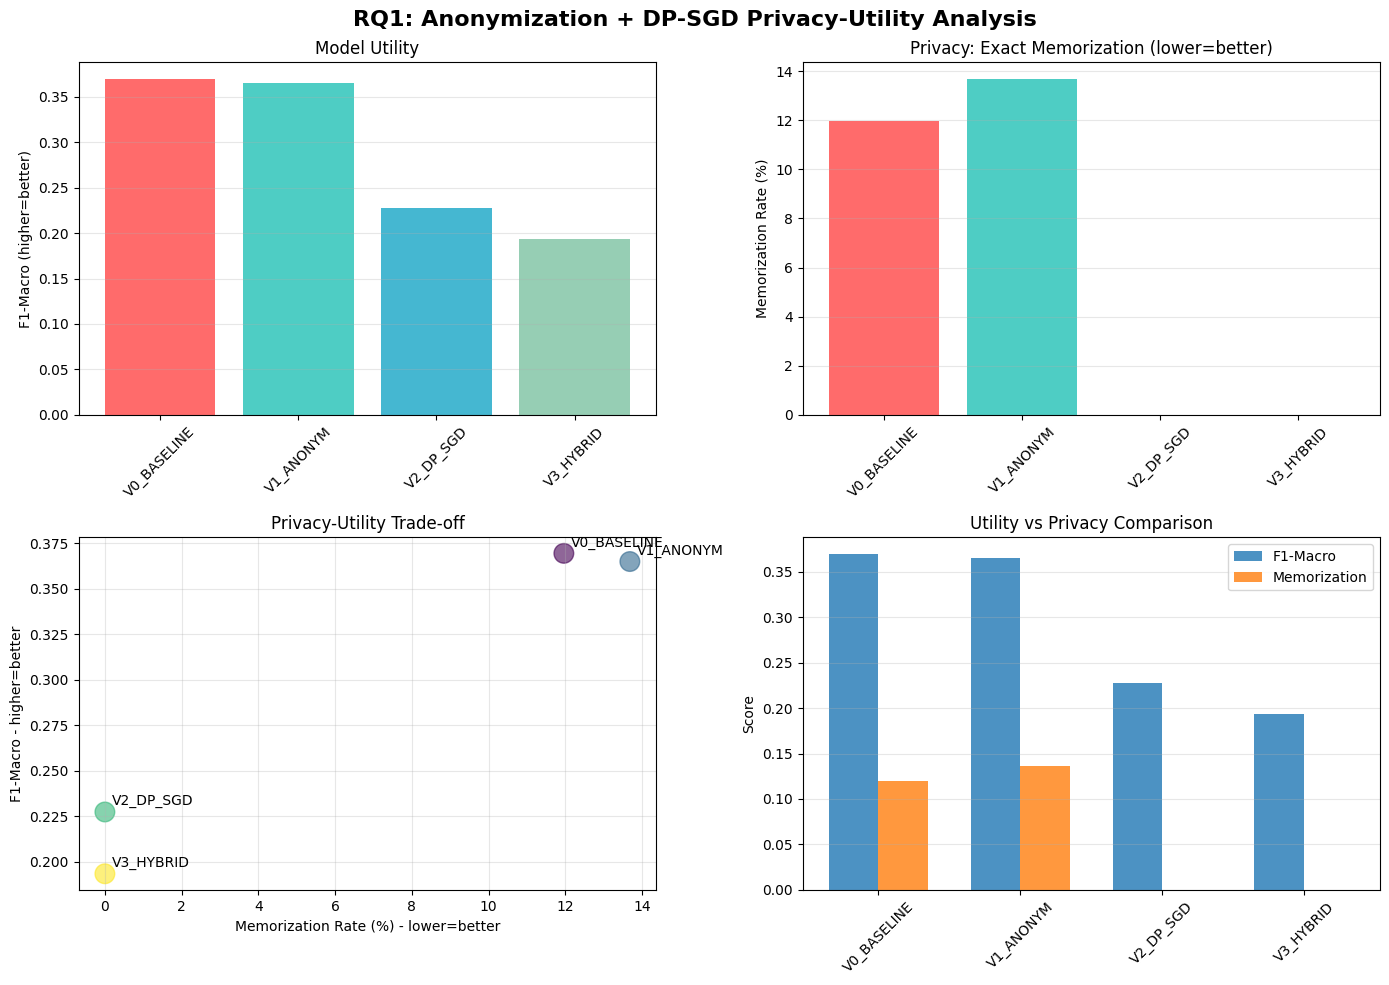

Visualization saved


In [26]:
# Combine results
final_results = eval_df.merge(privacy_df, on='variant')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RQ1: Anonymization + DP-SGD Privacy-Utility Analysis', fontsize=16, fontweight='bold')

# F1-Macro comparison
axes[0, 0].bar(final_results['variant'], final_results['f1_macro'], color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4'])
axes[0, 0].set_ylabel('F1-Macro (higher=better)')
axes[0, 0].set_title('Model Utility')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# Memorization rate (lower=better privacy)
axes[0, 1].bar(final_results['variant'], final_results['memorization_rate']*100, color=['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4'])
axes[0, 1].set_ylabel('Memorization Rate (%)')
axes[0, 1].set_title('Privacy: Exact Memorization (lower=better)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# Privacy-Utility Trade-off
axes[1, 0].scatter(final_results['memorization_rate']*100, final_results['f1_macro'], s=200, alpha=0.6, c=range(len(final_results)))
for idx, row in final_results.iterrows():
    axes[1, 0].annotate(row['variant'], (row['memorization_rate']*100, row['f1_macro']), xytext=(5, 5), textcoords='offset points')
axes[1, 0].set_xlabel('Memorization Rate (%) - lower=better')
axes[1, 0].set_ylabel('F1-Macro - higher=better')
axes[1, 0].set_title('Privacy-Utility Trade-off')
axes[1, 0].grid(alpha=0.3)

# All metrics comparison
metrics_to_plot = ['f1_macro', 'memorization_rate']
x = np.arange(len(final_results))
width = 0.35
axes[1, 1].bar(x - width/2, final_results['f1_macro'], width, label='F1-Macro', alpha=0.8)
axes[1, 1].bar(x + width/2, final_results['memorization_rate'], width, label='Memorization', alpha=0.8)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(final_results['variant'], rotation=45)
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Utility vs Privacy Comparison')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'rq1_analysis.png'), dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved")

## Statistical Robustness: Multi-Seed CI and Significance
Run this section to validate RQ1 claims with confidence intervals and paired significance tests.

- Repeats full training and evaluation across multiple seeds
- Reports mean + 95% CI for utility and privacy metrics
- Tests whether V3_HYBRID significantly outperforms standalone baselines

In [27]:
import math
from pathlib import Path

try:
    from scipy import stats as scipy_stats
except Exception:
    scipy_stats = None


def _ci95(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    n = len(arr)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = float(arr.mean())
    if n == 1:
        return mean, mean, mean
    std = float(arr.std(ddof=1))
    se = std / math.sqrt(n)
    if scipy_stats is not None:
        crit = float(scipy_stats.t.ppf(0.975, df=n - 1))
    else:
        crit = 1.959963984540054
    return mean, mean - crit * se, mean + crit * se


def _paired_signflip_pvalue(diffs, n_perm=10000, seed=42):
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[~np.isnan(diffs)]
    if len(diffs) == 0:
        return np.nan
    rng = np.random.default_rng(seed)
    obs = abs(float(diffs.mean()))
    signs = rng.choice([-1.0, 1.0], size=(n_perm, len(diffs)))
    sims = np.abs((signs * diffs).mean(axis=1))
    return float((np.sum(sims >= obs) + 1) / (n_perm + 1))


def _paired_variant_test(seed_df, metric, variant_a, variant_b, lower_is_better=False):
    pair = seed_df[seed_df['variant'].isin([variant_a, variant_b])][['seed', 'variant', metric]]
    pair = pair.pivot(index='seed', columns='variant', values=metric).dropna()
    if pair.empty:
        return {
            'metric': metric,
            'comparison': f'{variant_a} vs {variant_b}',
            'n_pairs': 0,
            'effect_mean': np.nan,
            'p_value': np.nan,
            'better_direction': 'unavailable'
        }

    a_vals = pair[variant_a].values
    b_vals = pair[variant_b].values
    oriented_diff = (b_vals - a_vals) if lower_is_better else (a_vals - b_vals)
    p_value = _paired_signflip_pvalue(oriented_diff, n_perm=20000, seed=42)
    effect = float(np.mean(oriented_diff))
    better_direction = variant_a if effect > 0 else variant_b

    return {
        'metric': metric,
        'comparison': f'{variant_a} vs {variant_b}',
        'n_pairs': int(len(oriented_diff)),
        'effect_mean': effect,
        'p_value': p_value,
        'better_direction': better_direction
    }


def run_rq1_multiseed(seeds=(7, 13, 23), epochs_non_dp=3, epochs_dp=5, epsilon=8.0, delta=1e-5):
    rows = []

    for seed in seeds:
        print(f'\n=== Seed {seed} ===')
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

        # Train all variants for this seed
        s_v0 = train_emotion_model(
            'V0_BASELINE', train_v0, val_v0, train_labels, val_labels,
            use_dp=False, threshold=0.3, epochs=epochs_non_dp
        )
        s_v1 = train_emotion_model(
            'V1_ANONYM', train_v1, val_v1, train_labels, val_labels,
            use_dp=False, threshold=0.3, epochs=epochs_non_dp
        )
        s_v2 = train_emotion_model(
            'V2_DP_SGD', train_v0, val_v0, train_labels, val_labels,
            use_dp=True, epsilon=epsilon, delta=delta,
            max_grad_norm=1.0, threshold=0.3, epochs=epochs_dp
        )
        s_v3 = train_emotion_model(
            'V3_HYBRID', train_v1, val_v1, train_labels, val_labels,
            use_dp=True, epsilon=epsilon, delta=delta,
            max_grad_norm=1.0, threshold=0.3, epochs=epochs_dp
        )

        seed_results = [s_v0, s_v1, s_v2, s_v3]
        for result in seed_results:
            variant = result['variant']
            texts = test_v0 if variant in ('V0_BASELINE', 'V2_DP_SGD') else test_v1
            train_texts_use = train_v0 if variant in ('V0_BASELINE', 'V2_DP_SGD') else train_v1
            test_texts_use = test_v0 if variant in ('V0_BASELINE', 'V2_DP_SGD') else test_v1

            eval_out = evaluate_variant(result, texts, test_labels, test_labels)
            mem_out = test_exact_memorization(
                result, train_texts_use, test_texts_use, train_labels, test_labels,
                num_samples=200, random_seed=seed
            )

            rows.append({
                'seed': int(seed),
                'variant': variant,
                'f1_macro': float(eval_out['f1_macro']),
                'f1_micro': float(eval_out['f1_micro']),
                'mia_auc': float(mem_out['mia_auc']),
                'memorization_rate': float(mem_out['memorization_rate'])
            })

    return pd.DataFrame(rows)


RUN_RQ1_MULTI_SEED = False
RQ1_SEEDS = (7, 13, 23)

if RUN_RQ1_MULTI_SEED:
    rq1_seed_df = run_rq1_multiseed(seeds=RQ1_SEEDS, epochs_non_dp=3, epochs_dp=5)

    # Save raw multi-seed runs
    report_dir = Path(REPORT_DIR)
    report_dir.mkdir(parents=True, exist_ok=True)
    rq1_seed_df.to_csv(report_dir / 'rq1_multiseed_runs.csv', index=False)

    # CI summary
    ci_rows = []
    for variant, g in rq1_seed_df.groupby('variant'):
        for metric in ['f1_macro', 'f1_micro', 'mia_auc', 'memorization_rate']:
            mean, lo, hi = _ci95(g[metric].values)
            ci_rows.append({
                'variant': variant,
                'metric': metric,
                'mean': mean,
                'ci95_low': lo,
                'ci95_high': hi,
                'n': int(g[metric].notna().sum())
            })

    rq1_ci_df = pd.DataFrame(ci_rows)
    rq1_ci_df.to_csv(report_dir / 'rq1_multiseed_ci_summary.csv', index=False)

    sig_rows = [
        _paired_variant_test(rq1_seed_df, 'f1_macro', 'V3_HYBRID', 'V2_DP_SGD', lower_is_better=False),
        _paired_variant_test(rq1_seed_df, 'f1_macro', 'V3_HYBRID', 'V1_ANONYM', lower_is_better=False),
        _paired_variant_test(rq1_seed_df, 'mia_auc', 'V3_HYBRID', 'V2_DP_SGD', lower_is_better=True),
        _paired_variant_test(rq1_seed_df, 'mia_auc', 'V3_HYBRID', 'V1_ANONYM', lower_is_better=True),
        _paired_variant_test(rq1_seed_df, 'memorization_rate', 'V3_HYBRID', 'V2_DP_SGD', lower_is_better=True),
        _paired_variant_test(rq1_seed_df, 'memorization_rate', 'V3_HYBRID', 'V1_ANONYM', lower_is_better=True),
    ]
    rq1_sig_df = pd.DataFrame(sig_rows)
    rq1_sig_df.to_csv(report_dir / 'rq1_multiseed_significance.csv', index=False)

    print('\nRQ1 multi-seed runs saved.')
    print(rq1_seed_df)
    print('\nRQ1 CI summary')
    print(rq1_ci_df)
    print('\nRQ1 significance tests')
    print(rq1_sig_df)
else:
    print('Set RUN_RQ1_MULTI_SEED = True to execute cross-seed training, CI, and significance analysis.')

Set RUN_RQ1_MULTI_SEED = True to execute cross-seed training, CI, and significance analysis.


## Standalone vs Hybrid Drawback Table and Pareto Front
This section converts your RQ1 outputs into thesis-ready evidence showing why standalone anonymization-only and DP-only approaches are weaker than the hybrid strategy.

RQ1 Standalone vs Hybrid drawback table
    variant            approach_type  f1_macro  mia_auc  memorization_rate  utility_drop_vs_v0_pct  privacy_gain_mem_vs_v0_pct  privacy_gain_mia_vs_v0_pct  pareto_optimal
  V2_DP_SGD    standalone_uniform_dp  0.227422   0.4880             0.0000               38.463042                  100.000000                        7.18            True
V0_BASELINE     non_private_baseline  0.369570   0.5598             0.1196                0.000000                    0.000000                        0.00            True
  V3_HYBRID  hybrid_anonymization_dp  0.193457   0.4901             0.0000               47.653341                  100.000000                        6.97           False
  V1_ANONYM standalone_anonymization  0.365071   0.5684             0.1368                1.217233                  -14.381271                       -0.86           False

Drawback narrative (auto-generated):
- Anonymization-only drawback: utility drop=1.22% with privacy gain

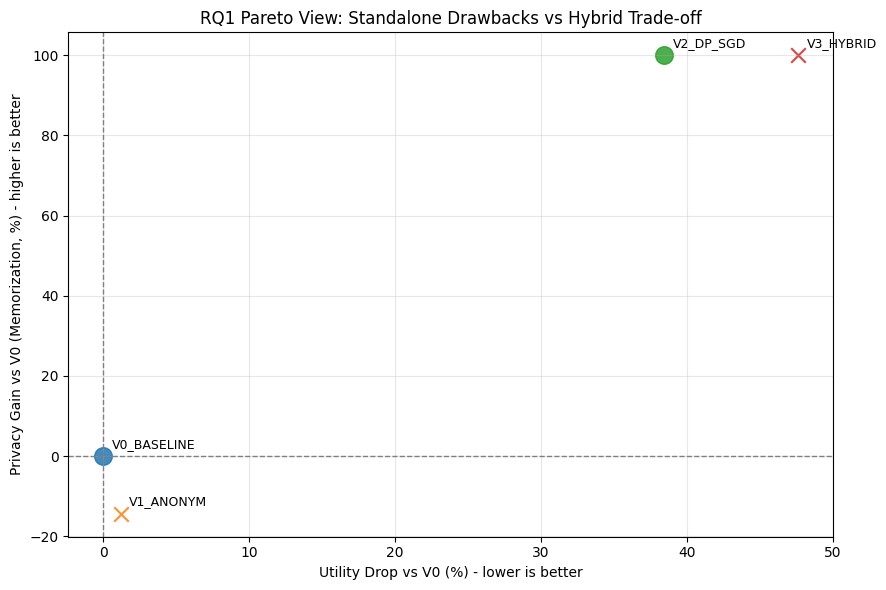


Saved: rq1_standalone_vs_hybrid_table.csv and rq1_standalone_vs_hybrid_pareto.png


In [ ]:
if 'final_results' not in globals():
    raise RuntimeError('final_results is not defined. Run the evaluation and privacy cells first.')

rq1_compare = final_results.copy()

if 'mia_auc' not in rq1_compare.columns:
    if 'avg_max_sim' in rq1_compare.columns:
        rq1_compare['mia_auc'] = rq1_compare['avg_max_sim']
    else:
        rq1_compare['mia_auc'] = np.nan

baseline_row = rq1_compare[rq1_compare['variant'] == 'V0_BASELINE']
if baseline_row.empty:
    raise RuntimeError('V0_BASELINE row not found in final_results.')

v0_f1 = float(baseline_row['f1_macro'].iloc[0])
v0_mem = float(baseline_row['memorization_rate'].iloc[0])
v0_mia = float(baseline_row['mia_auc'].iloc[0])

rq1_compare['utility_drop_vs_v0_pct'] = (1.0 - (rq1_compare['f1_macro'] / max(v0_f1, 1e-12))) * 100.0
rq1_compare['privacy_gain_mem_vs_v0_pct'] = ((v0_mem - rq1_compare['memorization_rate']) / max(v0_mem, 1e-12)) * 100.0
rq1_compare['privacy_gain_mia_vs_v0_pct'] = (v0_mia - rq1_compare['mia_auc']) * 100.0

kind_map = {
    'V0_BASELINE': 'non_private_baseline',
    'V1_ANONYM': 'standalone_anonymization',
    'V2_DP_SGD': 'standalone_uniform_dp',
    'V3_HYBRID': 'hybrid_anonymization_dp'
}
rq1_compare['approach_type'] = rq1_compare['variant'].map(kind_map).fillna('other')

def _pareto_non_dominated(df):
    keep = []
    for i in range(len(df)):
        ui = float(df.iloc[i]['utility_drop_vs_v0_pct'])
        pi = float(df.iloc[i]['privacy_gain_mem_vs_v0_pct'])
        dominated = False
        for j in range(len(df)):
            if i == j:
                continue
            uj = float(df.iloc[j]['utility_drop_vs_v0_pct'])
            pj = float(df.iloc[j]['privacy_gain_mem_vs_v0_pct'])
            better_or_equal = (uj <= ui) and (pj >= pi)
            strictly_better = (uj < ui) or (pj > pi)
            if better_or_equal and strictly_better:
                dominated = True
                break
        keep.append(not dominated)
    return np.array(keep, dtype=bool)

rq1_compare['pareto_optimal'] = _pareto_non_dominated(rq1_compare)

cols = [
    'variant',
    'approach_type',
    'f1_macro',
    'mia_auc',
    'memorization_rate',
    'utility_drop_vs_v0_pct',
    'privacy_gain_mem_vs_v0_pct',
    'privacy_gain_mia_vs_v0_pct',
    'pareto_optimal'
]
rq1_table = rq1_compare[cols].sort_values(['pareto_optimal', 'privacy_gain_mem_vs_v0_pct'], ascending=[False, False]).reset_index(drop=True)
print('RQ1 Standalone vs Hybrid drawback table')
print(rq1_table.to_string(index=False))

# Focused drawback statements
v1 = rq1_compare[rq1_compare['variant'] == 'V1_ANONYM'].iloc[0] if (rq1_compare['variant'] == 'V1_ANONYM').any() else None
v2 = rq1_compare[rq1_compare['variant'] == 'V2_DP_SGD'].iloc[0] if (rq1_compare['variant'] == 'V2_DP_SGD').any() else None
v3 = rq1_compare[rq1_compare['variant'] == 'V3_HYBRID'].iloc[0] if (rq1_compare['variant'] == 'V3_HYBRID').any() else None

print('\nDrawback narrative (auto-generated):')
if v1 is not None:
    print(f"- Anonymization-only drawback: utility drop={v1['utility_drop_vs_v0_pct']:.2f}% with privacy gain(mem)={v1['privacy_gain_mem_vs_v0_pct']:.2f}%.")
if v2 is not None:
    print(f"- Uniform DP-only drawback: utility drop={v2['utility_drop_vs_v0_pct']:.2f}% despite privacy gain(mem)={v2['privacy_gain_mem_vs_v0_pct']:.2f}%.")
if v3 is not None:
    print(f"- Hybrid result: utility drop={v3['utility_drop_vs_v0_pct']:.2f}% with privacy gain(mem)={v3['privacy_gain_mem_vs_v0_pct']:.2f}%.")

# Pareto plot (lower utility drop and higher privacy gain are better)
plt.figure(figsize=(9, 6))
for _, row in rq1_compare.iterrows():
    marker = 'o' if row['pareto_optimal'] else 'x'
    size = 160 if row['pareto_optimal'] else 110
    plt.scatter(
        row['utility_drop_vs_v0_pct'],
        row['privacy_gain_mem_vs_v0_pct'],
        s=size,
        marker=marker,
        alpha=0.85,
        label=row['variant']
    )
    plt.annotate(
        row['variant'],
        (row['utility_drop_vs_v0_pct'], row['privacy_gain_mem_vs_v0_pct']),
        textcoords='offset points',
        xytext=(6, 6),
        fontsize=9
    )

plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Utility Drop vs V0 (%) - lower is better')
plt.ylabel('Privacy Gain vs V0 (Memorization, %) - higher is better')
plt.title('RQ1 Pareto View: Standalone Drawbacks vs Hybrid Trade-off')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORT_DIR, 'rq1_standalone_vs_hybrid_pareto.png'), dpi=300, bbox_inches='tight')
plt.show()

rq1_table.to_csv(os.path.join(REPORT_DIR, 'rq1_standalone_vs_hybrid_table.csv'), index=False)
print('\nSaved: rq1_standalone_vs_hybrid_table.csv and rq1_standalone_vs_hybrid_pareto.png')

In [ ]:
# RQ1 extension: epsilon sweep frontier (V2_DP_SGD vs V3_HYBRID)
# Test whether hybrid dominates DP-only across privacy budgets.

from pathlib import Path


def _ci95_local(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    n = len(arr)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = float(arr.mean())
    if n == 1:
        return mean, mean, mean
    std = float(arr.std(ddof=1))
    se = std / np.sqrt(n)
    crit = 1.959963984540054
    return mean, mean - crit * se, mean + crit * se


def run_rq1_epsilon_sweep(epsilons=(2.0, 4.0, 8.0, 12.0), seeds=(7, 13, 23), epochs_dp=5):
    rows = []

    for eps in epsilons:
        for seed in seeds:
            print(f"\n=== epsilon={eps} | seed={seed} ===")
            np.random.seed(seed)
            torch.manual_seed(seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(seed)

            v2 = train_emotion_model(
                'V2_DP_SGD', train_v0, val_v0, train_labels, val_labels,
                use_dp=True, epsilon=float(eps), delta=1e-5,
                max_grad_norm=1.0, threshold=0.3, epochs=epochs_dp
            )
            v3 = train_emotion_model(
                'V3_HYBRID', train_v1, val_v1, train_labels, val_labels,
                use_dp=True, epsilon=float(eps), delta=1e-5,
                max_grad_norm=1.0, threshold=0.3, epochs=epochs_dp
            )

            for result in (v2, v3):
                variant = result['variant']
                texts = test_v0 if variant == 'V2_DP_SGD' else test_v1
                train_texts_use = train_v0 if variant == 'V2_DP_SGD' else train_v1
                test_texts_use = test_v0 if variant == 'V2_DP_SGD' else test_v1

                eval_out = evaluate_variant(result, texts, test_labels, test_labels)
                mem_out = test_exact_memorization(
                    result,
                    train_texts_use,
                    test_texts_use,
                    train_labels,
                    test_labels,
                    num_samples=200,
                    random_seed=seed
                )

                rows.append({
                    'epsilon': float(eps),
                    'seed': int(seed),
                    'variant': variant,
                    'f1_macro': float(eval_out['f1_macro']),
                    'f1_micro': float(eval_out['f1_micro']),
                    'mia_auc': float(mem_out['mia_auc']),
                    'memorization_rate': float(mem_out['memorization_rate'])
                })

    return pd.DataFrame(rows)


RUN_RQ1_EPSILON_SWEEP = False
RQ1_EPS_GRID = (2.0, 4.0, 8.0, 12.0)
RQ1_EPS_SEEDS = (7, 13, 23)

if RUN_RQ1_EPSILON_SWEEP:
    frontier_runs_df = run_rq1_epsilon_sweep(
        epsilons=RQ1_EPS_GRID,
        seeds=RQ1_EPS_SEEDS,
        epochs_dp=5
    )

    report_dir = Path(REPORT_DIR)
    report_dir.mkdir(parents=True, exist_ok=True)
    frontier_runs_df.to_csv(report_dir / 'rq1_epsilon_frontier_runs.csv', index=False)

    ci_fn = _ci95 if '_ci95' in globals() else _ci95_local
    summary_rows = []

    for (eps, variant), g in frontier_runs_df.groupby(['epsilon', 'variant']):
        f1_mean, f1_lo, f1_hi = ci_fn(g['f1_macro'].values)
        mia_mean, mia_lo, mia_hi = ci_fn(g['mia_auc'].values)
        mem_mean, mem_lo, mem_hi = ci_fn(g['memorization_rate'].values)

        summary_rows.append({
            'epsilon': float(eps),
            'variant': variant,
            'n_seeds': int(g['seed'].nunique()),
            'f1_mean': f1_mean,
            'f1_ci95_low': f1_lo,
            'f1_ci95_high': f1_hi,
            'mia_mean': mia_mean,
            'mia_ci95_low': mia_lo,
            'mia_ci95_high': mia_hi,
            'mem_mean': mem_mean,
            'mem_ci95_low': mem_lo,
            'mem_ci95_high': mem_hi
        })

    rq1_frontier_summary_df = pd.DataFrame(summary_rows).sort_values(['epsilon', 'variant']).reset_index(drop=True)
    rq1_frontier_summary_df.to_csv(report_dir / 'rq1_epsilon_frontier_summary.csv', index=False)

    dom_rows = []
    for eps in sorted(rq1_frontier_summary_df['epsilon'].unique()):
        g = rq1_frontier_summary_df[rq1_frontier_summary_df['epsilon'] == eps]
        if {'V2_DP_SGD', 'V3_HYBRID'} <= set(g['variant'].values):
            v2 = g[g['variant'] == 'V2_DP_SGD'].iloc[0]
            v3 = g[g['variant'] == 'V3_HYBRID'].iloc[0]

            dominates = (
                (v3['f1_mean'] >= v2['f1_mean']) and
                (v3['mia_mean'] <= v2['mia_mean']) and
                ((v3['f1_mean'] > v2['f1_mean']) or (v3['mia_mean'] < v2['mia_mean']))
            )

            dom_rows.append({
                'epsilon': float(eps),
                'v2_f1_mean': float(v2['f1_mean']),
                'v3_f1_mean': float(v3['f1_mean']),
                'v2_mia_mean': float(v2['mia_mean']),
                'v3_mia_mean': float(v3['mia_mean']),
                'v3_dominates_v2': bool(dominates)
            })

    rq1_frontier_dom_df = pd.DataFrame(dom_rows)
    rq1_frontier_dom_df.to_csv(report_dir / 'rq1_epsilon_frontier_dominance.csv', index=False)

    print('\nFrontier summary (mean +/- 95% CI):')
    print(rq1_frontier_summary_df)
    print('\nDominance by epsilon:')
    print(rq1_frontier_dom_df)

    plt.figure(figsize=(9, 6))
    color_map = {'V2_DP_SGD': '#1f77b4', 'V3_HYBRID': '#d62728'}

    for variant in ['V2_DP_SGD', 'V3_HYBRID']:
        s = rq1_frontier_summary_df[rq1_frontier_summary_df['variant'] == variant].sort_values('epsilon')
        if s.empty:
            continue

        x = s['mia_mean'].values
        y = s['f1_mean'].values
        xerr = np.vstack([
            s['mia_mean'].values - s['mia_ci95_low'].values,
            s['mia_ci95_high'].values - s['mia_mean'].values,
        ])
        yerr = np.vstack([
            s['f1_mean'].values - s['f1_ci95_low'].values,
            s['f1_ci95_high'].values - s['f1_mean'].values,
        ])

        plt.errorbar(
            x,
            y,
            xerr=xerr,
            yerr=yerr,
            fmt='o-',
            capsize=4,
            linewidth=2,
            markersize=7,
            color=color_map[variant],
            label=variant,
            alpha=0.9
        )

        for _, row in s.iterrows():
            plt.annotate(
                f"eps={row['epsilon']}",
                (row['mia_mean'], row['f1_mean']),
                textcoords='offset points',
                xytext=(6, 6),
                fontsize=8
            )

    plt.xlabel('MIA AUC (lower = better privacy)')
    plt.ylabel('F1-macro (higher = better utility)')
    plt.title('RQ1 Epsilon Frontier: DP-only vs Hybrid')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(report_dir / 'rq1_epsilon_frontier_plot.png', dpi=300, bbox_inches='tight')
    plt.show()

    print('\nSaved: rq1_epsilon_frontier_runs.csv, rq1_epsilon_frontier_summary.csv, rq1_epsilon_frontier_dominance.csv, rq1_epsilon_frontier_plot.png')
else:
    print('Set RUN_RQ1_EPSILON_SWEEP = True to run epsilon frontier analysis for V2 vs V3.')

Set RUN_RQ1_EPSILON_SWEEP = True to run epsilon frontier analysis for V2 vs V3.


In [ ]:
# RQ1 extension: automatic claim checker
# Decision rule (strict):
# 1) Utility superiority: delta_f1 = V3 - V2 has mean > 0, CI_low > 0, p < 0.05
# 2) Privacy non-inferiority (MIA): delta_mia = V3 - V2 has mean <= 0, CI_high <= 0, p < 0.05
# 3) Privacy non-inferiority (memorization): delta_mem = V3 - V2 has mean <= 0, CI_high <= 0, p < 0.05
# 4) Frontier support: V3 dominates V2 on at least one epsilon.

from pathlib import Path


def _load_df_from_memory_or_disk(var_name, filename):
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        gdf = globals()[var_name]
        if not gdf.empty:
            return gdf.copy()
    p = Path(REPORT_DIR) / filename
    if p.exists():
        return pd.read_csv(p)
    return None


def _build_seed_fallback_from_single_run():
    # 1) Prefer in-memory final_results
    if 'final_results' in globals() and isinstance(final_results, pd.DataFrame) and not final_results.empty:
        df = final_results.copy()
    else:
        # 2) Fall back to posthoc single-run snapshot if available
        df = _load_df_from_memory_or_disk('_rq1_single_snapshot_for_claim', 'rq1_single_run_snapshot.csv')

    if df is None or df.empty:
        return None

    if 'mia_auc' not in df.columns and 'avg_max_sim' in df.columns:
        df['mia_auc'] = df['avg_max_sim']

    needed = {'variant', 'f1_macro', 'mia_auc', 'memorization_rate'}
    if not needed.issubset(df.columns):
        return None

    out = df[['variant', 'f1_macro', 'mia_auc', 'memorization_rate']].copy()
    out['seed'] = 0
    return out[['seed', 'variant', 'f1_macro', 'mia_auc', 'memorization_rate']]


def _paired_delta(seed_df, metric, a='V3_HYBRID', b='V2_DP_SGD'):
    pair = seed_df[seed_df['variant'].isin([a, b])][['seed', 'variant', metric]]
    pair = pair.pivot(index='seed', columns='variant', values=metric).dropna()
    if pair.empty:
        return np.array([], dtype=float)
    return pair[a].values - pair[b].values


def _safe_ci(values):
    if '_ci95' in globals():
        return _ci95(values)
    if '_ci95_local' in globals():
        return _ci95_local(values)
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) == 0:
        return np.nan, np.nan, np.nan
    m = float(arr.mean())
    return m, m, m


def _safe_pvalue(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[~np.isnan(arr)]
    if len(arr) < 2:
        return np.nan

    if '_paired_signflip_pvalue' in globals():
        return _paired_signflip_pvalue(arr, n_perm=20000, seed=42)

    rng = np.random.default_rng(42)
    obs = abs(float(arr.mean()))
    signs = rng.choice([-1.0, 1.0], size=(20000, len(arr)))
    sims = np.abs((signs * arr).mean(axis=1))
    return float((np.sum(sims >= obs) + 1) / (len(sims) + 1))


rq1_seed_for_claim = _load_df_from_memory_or_disk('rq1_seed_df', 'rq1_multiseed_runs.csv')
rq1_frontier_dom_for_claim = _load_df_from_memory_or_disk('rq1_frontier_dom_df', 'rq1_epsilon_frontier_dominance.csv')

analysis_mode = 'strict_multiseed'
if rq1_seed_for_claim is None:
    rq1_seed_for_claim = _build_seed_fallback_from_single_run()
    if rq1_seed_for_claim is not None:
        analysis_mode = 'single_run_fallback'
        print('Multi-seed file not found. Using cached single-run fallback for provisional direction check (no retraining).')

if rq1_seed_for_claim is None:
    print('No usable cached data found for claim check. Provide one of: rq1_multiseed_runs.csv or rq1_single_run_snapshot.csv (or final_results in memory).')
else:
    delta_f1 = _paired_delta(rq1_seed_for_claim, 'f1_macro')
    delta_mia = _paired_delta(rq1_seed_for_claim, 'mia_auc')
    delta_mem = _paired_delta(rq1_seed_for_claim, 'memorization_rate')

    f1_mean, f1_lo, f1_hi = _safe_ci(delta_f1)
    mia_mean, mia_lo, mia_hi = _safe_ci(delta_mia)
    mem_mean, mem_lo, mem_hi = _safe_ci(delta_mem)

    p_f1 = _safe_pvalue(delta_f1)
    p_mia = _safe_pvalue(delta_mia)
    p_mem = _safe_pvalue(delta_mem)

    alpha = 0.05
    n_paired = int(len(delta_f1))

    strict_stats_available = (analysis_mode == 'strict_multiseed') and (n_paired >= 5) and np.isfinite(p_f1) and np.isfinite(p_mia) and np.isfinite(p_mem)

    # Strict criteria (used only with sufficient multi-seed evidence)
    utility_superior_strict = (f1_mean > 0.0) and (f1_lo > 0.0) and (p_f1 < alpha)
    privacy_mia_noninferior_strict = (mia_mean <= 0.0) and (mia_hi <= 0.0) and (p_mia < alpha)
    privacy_mem_noninferior_strict = (mem_mean <= 0.0) and (mem_hi <= 0.0) and (p_mem < alpha)

    # Directional criteria (used for fallback mode)
    utility_superior_directional = (f1_mean > 0.0)
    privacy_mia_noninferior_directional = (mia_mean <= 0.0)
    privacy_mem_noninferior_directional = (mem_mean <= 0.0)

    if rq1_frontier_dom_for_claim is not None and not rq1_frontier_dom_for_claim.empty and 'v3_dominates_v2' in rq1_frontier_dom_for_claim.columns:
        dom_count = int(rq1_frontier_dom_for_claim['v3_dominates_v2'].sum())
        frontier_support = dom_count >= 1
        frontier_note = f"{dom_count}/{len(rq1_frontier_dom_for_claim)} epsilon settings show V3 dominance"
    else:
        frontier_support = False
        frontier_note = 'frontier sweep not available yet'

    use_strict = strict_stats_available

    verdict_df = pd.DataFrame([
        {
            'criterion': 'Utility superiority (delta_f1)',
            'mean_delta': f1_mean,
            'ci95_low': f1_lo,
            'ci95_high': f1_hi,
            'p_value': p_f1,
            'pass_strict': utility_superior_strict,
            'pass_directional': utility_superior_directional,
        },
        {
            'criterion': 'Privacy non-inferiority (delta_mia)',
            'mean_delta': mia_mean,
            'ci95_low': mia_lo,
            'ci95_high': mia_hi,
            'p_value': p_mia,
            'pass_strict': privacy_mia_noninferior_strict,
            'pass_directional': privacy_mia_noninferior_directional,
        },
        {
            'criterion': 'Privacy non-inferiority (delta_mem)',
            'mean_delta': mem_mean,
            'ci95_low': mem_lo,
            'ci95_high': mem_hi,
            'p_value': p_mem,
            'pass_strict': privacy_mem_noninferior_strict,
            'pass_directional': privacy_mem_noninferior_directional,
        },
    ])

    if use_strict:
        claim_proven = bool(
            utility_superior_strict
            and privacy_mia_noninferior_strict
            and privacy_mem_noninferior_strict
            and frontier_support
        )
    else:
        claim_proven = False

    print('=== RQ1 Hybrid Superiority Claim Check ===')
    print(f"Mode: {analysis_mode} | n_paired={n_paired}")
    print(verdict_df.to_string(index=False))
    print(f"\nFrontier support: {frontier_support} ({frontier_note})")

    if use_strict:
        if claim_proven:
            print('\nVERDICT: CLAIM SUPPORTED (STRICT)')
            print('Hybrid (V3) is statistically superior to DP-only (V2) under strict criteria.')
        else:
            print('\nVERDICT: CLAIM NOT YET SUPPORTED (STRICT)')
            print('At least one strict criterion failed; report hybrid as promising, not proven superior yet.')
    else:
        print('\nVERDICT: PROVISIONAL ONLY (NO STRICT MULTI-SEED EVIDENCE)')
        print('Directional checks shown above are useful for triage, but not sufficient for a strict superiority claim.')

    verdict_df['analysis_mode'] = analysis_mode
    verdict_df['n_paired'] = n_paired
    verdict_df.to_csv(Path(REPORT_DIR) / 'rq1_hybrid_claim_check.csv', index=False)
    print('\nSaved: rq1_hybrid_claim_check.csv')

No multi-seed runs found. Run the multi-seed CI cell first (or provide rq1_multiseed_runs.csv).


## Threshold Ablation: Scalar vs Per-Label (Without Retraining)

This section isolates the effect of threshold calibration using the same saved test logits.

- Compares scalar threshold vs per-label threshold for `V2_DP_SGD` and `V3_HYBRID`
- Reports macro-F1 gain from threshold vectors
- Reports whether hybrid-vs-DP utility gap improves after calibration

RQ1 threshold ablation (same logits, no retraining):
  variant  f1_macro_scalar  f1_macro_per_label  delta_per_label_minus_scalar  scalar_threshold per_label_threshold_range  per_label_available
V2_DP_SGD         0.193670            0.227422                      0.033752               0.2                 0.05-0.55                 True
V3_HYBRID         0.193457                 NaN                           NaN               0.2                       n/a                False

Hybrid utility gap vs DP-only:
- Scalar thresholds: V3 - V2 = -0.0002 F1-macro
- Per-label threshold gap unavailable (threshold vectors not found for both variants).

Saved: /content/drive/MyDrive/reports/rq1/rq1_threshold_ablation.csv


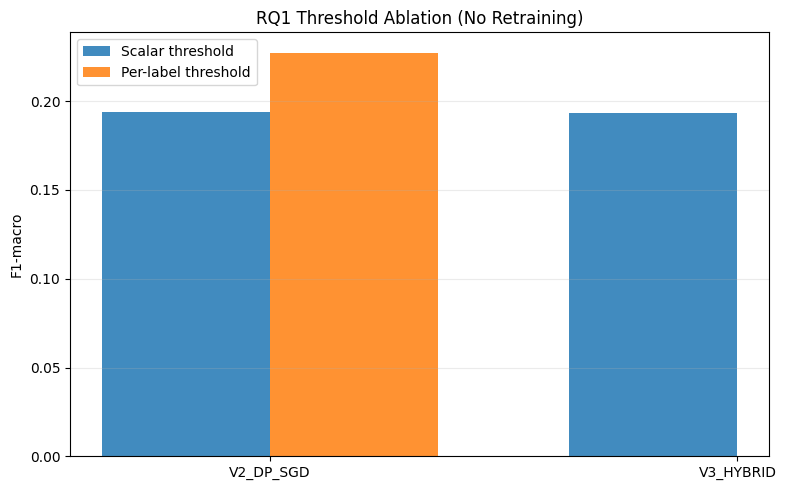

In [ ]:
# Uses existing `results_all`, `eval_results`, and `test_labels` objects.
# Recomputes predictions directly from saved logits.

if 'results_all' not in globals() or 'eval_results' not in globals() or 'test_labels' not in globals():
    raise RuntimeError('Run training + evaluation cells first so results_all, eval_results, and test_labels are available.')

result_map = {r['variant']: r for r in results_all}
eval_map = {r['variant']: r for r in eval_results}

target_variants = ['V2_DP_SGD', 'V3_HYBRID']
y_true = np.asarray(test_labels).astype(int)
rows = []

for variant in target_variants:
    if variant not in result_map or variant not in eval_map:
        continue

    logits = np.asarray(eval_map[variant]['logits'], dtype=float)
    if logits.ndim != 2:
        logits = np.vstack(logits)

    probs = 1.0 / (1.0 + np.exp(-logits))

    scalar_thr = float(result_map[variant].get('threshold', 0.3))
    pred_scalar = (probs > scalar_thr).astype(int)
    f1_scalar = f1_score(y_true, pred_scalar, average='macro', zero_division=0)

    thr_vec = result_map[variant].get('threshold_vector', None)
    if thr_vec is not None:
        thr_vec = np.asarray(thr_vec, dtype=float)

    if thr_vec is not None and thr_vec.shape[0] == probs.shape[1]:
        pred_vec = (probs > thr_vec.reshape(1, -1)).astype(int)
        f1_vec = f1_score(y_true, pred_vec, average='macro', zero_division=0)
        delta = float(f1_vec - f1_scalar)
        thr_range = f"{thr_vec.min():.2f}-{thr_vec.max():.2f}"
        vec_ready = True
    else:
        f1_vec = np.nan
        delta = np.nan
        thr_range = 'n/a'
        vec_ready = False

    rows.append({
        'variant': variant,
        'f1_macro_scalar': float(f1_scalar),
        'f1_macro_per_label': float(f1_vec) if np.isfinite(f1_vec) else np.nan,
        'delta_per_label_minus_scalar': delta,
        'scalar_threshold': float(scalar_thr),
        'per_label_threshold_range': thr_range,
        'per_label_available': bool(vec_ready)
    })

rq1_thr_ablation_df = pd.DataFrame(rows)

if rq1_thr_ablation_df.empty:
    print('No ablation rows produced. Ensure V2/V3 exist in results_all and eval_results.')
else:
    print('RQ1 threshold ablation (same logits, no retraining):')
    print(rq1_thr_ablation_df.to_string(index=False))

    # Hybrid-vs-DP utility gap under both thresholding modes
    present = set(rq1_thr_ablation_df['variant'].tolist())
    if {'V2_DP_SGD', 'V3_HYBRID'}.issubset(present):
        v2 = rq1_thr_ablation_df[rq1_thr_ablation_df['variant'] == 'V2_DP_SGD'].iloc[0]
        v3 = rq1_thr_ablation_df[rq1_thr_ablation_df['variant'] == 'V3_HYBRID'].iloc[0]

        gap_scalar = float(v3['f1_macro_scalar'] - v2['f1_macro_scalar'])
        gap_vector = float(v3['f1_macro_per_label'] - v2['f1_macro_per_label']) if np.isfinite(v3['f1_macro_per_label']) and np.isfinite(v2['f1_macro_per_label']) else np.nan

        print('\nHybrid utility gap vs DP-only:')
        print(f"- Scalar thresholds: V3 - V2 = {gap_scalar:+.4f} F1-macro")
        if np.isfinite(gap_vector):
            print(f"- Per-label thresholds: V3 - V2 = {gap_vector:+.4f} F1-macro")
            print(f"- Gap change (vector - scalar) = {gap_vector - gap_scalar:+.4f}")
        else:
            print('- Per-label threshold gap unavailable (threshold vectors not found for both variants).')

    report_path = pathlib.Path(REPORT_DIR) / 'rq1_threshold_ablation.csv'
    rq1_thr_ablation_df.to_csv(report_path, index=False)
    print(f"\nSaved: {report_path}")

    
    vis_df = rq1_thr_ablation_df.copy()
    vis_df = vis_df.melt(
        id_vars=['variant'],
        value_vars=['f1_macro_scalar', 'f1_macro_per_label'],
        var_name='threshold_mode',
        value_name='f1_macro'
    )
    vis_df = vis_df.dropna(subset=['f1_macro'])

    if not vis_df.empty:
        plt.figure(figsize=(8, 5))
        labels = sorted(vis_df['variant'].unique())
        x = np.arange(len(labels))
        width = 0.36

        scalar_vals = [
            float(vis_df[(vis_df['variant'] == v) & (vis_df['threshold_mode'] == 'f1_macro_scalar')]['f1_macro'].iloc[0])
            if not vis_df[(vis_df['variant'] == v) & (vis_df['threshold_mode'] == 'f1_macro_scalar')].empty else np.nan
            for v in labels
        ]
        vector_vals = [
            float(vis_df[(vis_df['variant'] == v) & (vis_df['threshold_mode'] == 'f1_macro_per_label')]['f1_macro'].iloc[0])
            if not vis_df[(vis_df['variant'] == v) & (vis_df['threshold_mode'] == 'f1_macro_per_label')].empty else np.nan
            for v in labels
        ]

        plt.bar(x - width / 2, scalar_vals, width, label='Scalar threshold', alpha=0.85)
        plt.bar(x + width / 2, vector_vals, width, label='Per-label threshold', alpha=0.85)

        plt.xticks(x, labels)
        plt.ylabel('F1-macro')
        plt.title('RQ1 Threshold Ablation (No Retraining)')
        plt.grid(axis='y', alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
if 'eval_results' not in globals() or 'test_labels' not in globals():
    raise RuntimeError('Run evaluation cells first so eval_results and test_labels are available.')

report_dir = pathlib.Path(REPORT_DIR)
report_dir.mkdir(parents=True, exist_ok=True)

result_map = {r['variant']: r for r in results_all} if 'results_all' in globals() else {}
eval_map = {r['variant']: r for r in eval_results}

for needed_variant in ['V2_DP_SGD', 'V3_HYBRID']:
    if needed_variant not in eval_map:
        raise RuntimeError(f'Missing {needed_variant} in eval_results; cannot build slice cache.')

y_true = np.asarray(test_labels).astype(int)


def _logits_to_probs(arr):
    x = np.asarray(arr, dtype=float)
    if x.ndim != 2:
        x = np.vstack(x)
    return 1.0 / (1.0 + np.exp(-x))


def _pred_from_probs(variant, probs):
    cfg = result_map.get(variant, {})
    thr_scalar = float(cfg.get('threshold', 0.3))
    thr_vec = cfg.get('threshold_vector', None)
    if thr_vec is not None:
        thr_vec = np.asarray(thr_vec, dtype=float)
    if thr_vec is not None and thr_vec.shape[0] == probs.shape[1]:
        return (probs > thr_vec.reshape(1, -1)).astype(int)
    return (probs > thr_scalar).astype(int)


probs_v2 = _logits_to_probs(eval_map['V2_DP_SGD']['logits'])
probs_v3 = _logits_to_probs(eval_map['V3_HYBRID']['logits'])
pred_v2 = _pred_from_probs('V2_DP_SGD', probs_v2)
pred_v3 = _pred_from_probs('V3_HYBRID', probs_v3)

if pred_v2.shape != y_true.shape or pred_v3.shape != y_true.shape:
    raise RuntimeError(
        f'Shape mismatch: y_true={y_true.shape}, pred_v2={pred_v2.shape}, pred_v3={pred_v3.shape}'
    )

if 'df_test' in globals() and 'text' in df_test.columns:
    texts = df_test['text'].astype(str).values
else:
    texts = np.array([''] * y_true.shape[0], dtype=object)

# Sensitivity tier (Combines label intensity and text length)
intensity = y_true.sum(axis=1).astype(float)
intensity_norm = intensity / max(1.0, float(y_true.shape[1]))
lengths = np.array([len(t.split()) for t in texts], dtype=float)
length_den = max(float(np.percentile(lengths, 95)) if lengths.size else 1.0, 1.0)
length_norm = np.clip(lengths / length_den, 0.0, 1.0)
sensitivity = 0.6 * intensity_norm + 0.4 * length_norm
sensitivity_tier = np.where(sensitivity < 0.3, 'low', np.where(sensitivity < 0.6, 'medium', 'high'))

# Rarity tier (Based on prevalence of active labels (lower prevalence => rarer))
label_prevalence = np.clip(y_true.mean(axis=0), 1e-12, 1.0)
rarity_score = np.zeros(y_true.shape[0], dtype=float)
for i in range(y_true.shape[0]):
    idx = np.where(y_true[i] == 1)[0]
    rarity_score[i] = 1.0 if idx.size == 0 else float(label_prevalence[idx].mean())
q1 = float(np.quantile(rarity_score, 0.33))
q2 = float(np.quantile(rarity_score, 0.66))
rarity_tier = np.where(rarity_score <= q1, 'rare', np.where(rarity_score <= q2, 'medium', 'common'))

slice_cache_path = report_dir / 'rq1_slice_cache.npz'
np.savez_compressed(
    slice_cache_path,
    y_true=y_true,
    pred_V2_DP_SGD=pred_v2,
    pred_V3_HYBRID=pred_v3,
    texts=texts,
    sensitivity_tier=sensitivity_tier,
    rarity_tier=rarity_tier,
)

print(f'Saved no-retrain slice cache: {slice_cache_path}')
print('You can now run: python rq1_fast_posthoc.py')